# Customer Segmentation with Actionable Business Insights

**Dataset:** `marketing_campaign.csv` (2,240 customers, e-commerce marketing campaign data)

**Goal:** Segment customers using K-Means clustering, predict customer value with regression,
predict purchase likelihood with classification, tune the models, and translate the results
into concrete marketing actions.


## 1. Imports and Data Loading

In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)


In [2]:
# Modeling libraries
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, silhouette_score
)


In [3]:
# Load the dataset (tab-separated)
df = pd.read_csv('marketing_campaign.csv', sep='\t')
df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


## 3. Exploratory Data Analysis

In [4]:
print("Shape:", df.shape)
df.dtypes


Shape: (2240, 29)


ID                       int64
Year_Birth               int64
Education                  str
Marital_Status             str
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer                str
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

In [5]:
# Missing values
df.isna().sum()[df.isna().sum() > 0]


Income    24
dtype: int64

In [6]:
# Duplicate records
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [7]:
# Statistical summary of numeric columns
df.describe().T


,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


In [8]:
# Categorical columns overview
print(df['Education'].value_counts())
print()
print(df['Marital_Status'].value_counts())


Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


### 3.1 Distributions and Outliers

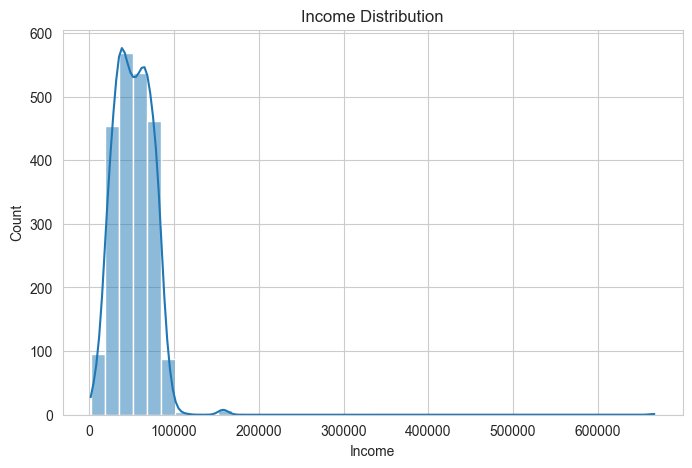

In [9]:
# Income distribution
fig, ax = plt.subplots()
sns.histplot(df['Income'].dropna(), bins=40, kde=True, ax=ax)
ax.set_title('Income Distribution')
plt.show()


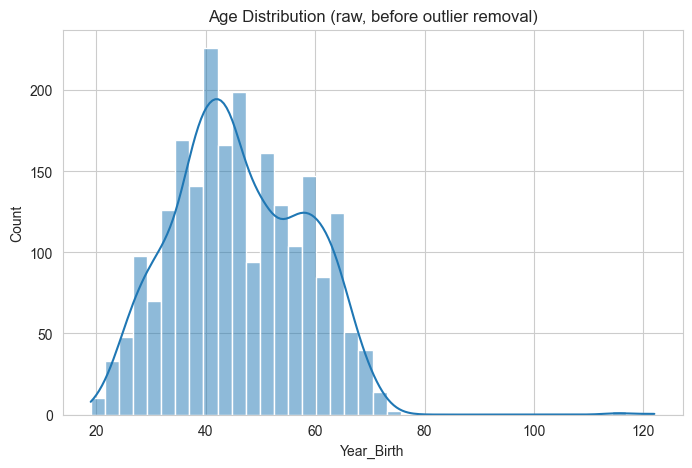

In [10]:
# Age distribution (Year_Birth converted to Age)
reference_year = 2015  # dataset was collected around 2014-2015
age_preview = reference_year - df['Year_Birth']
fig, ax = plt.subplots()
sns.histplot(age_preview, bins=40, kde=True, ax=ax)
ax.set_title('Age Distribution (raw, before outlier removal)')
plt.show()


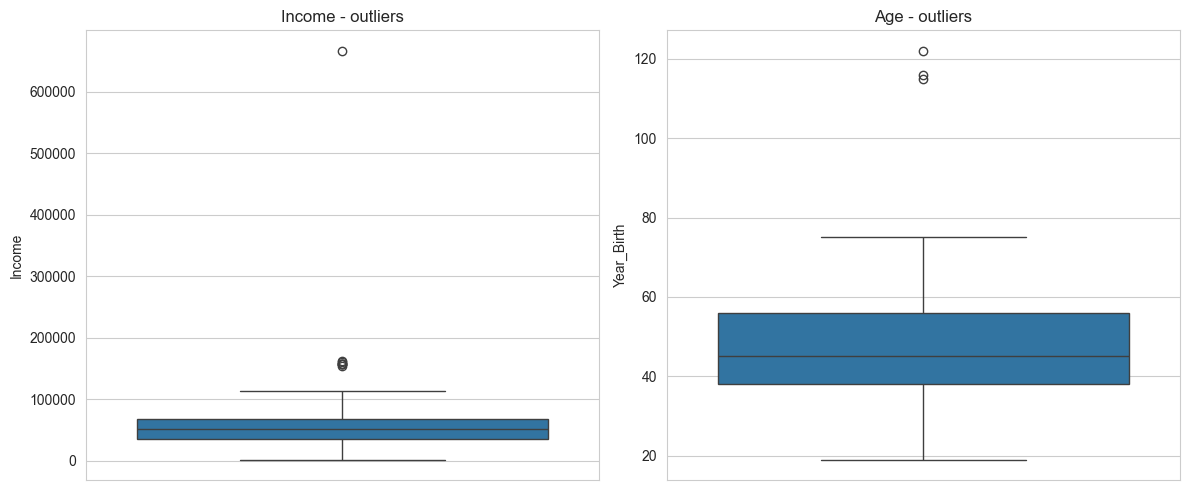

In [11]:
# Boxplots to spot outliers in Income and Age
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df['Income'], ax=axes[0])
axes[0].set_title('Income - outliers')
sns.boxplot(y=age_preview, ax=axes[1])
axes[1].set_title('Age - outliers')
plt.tight_layout()
plt.show()


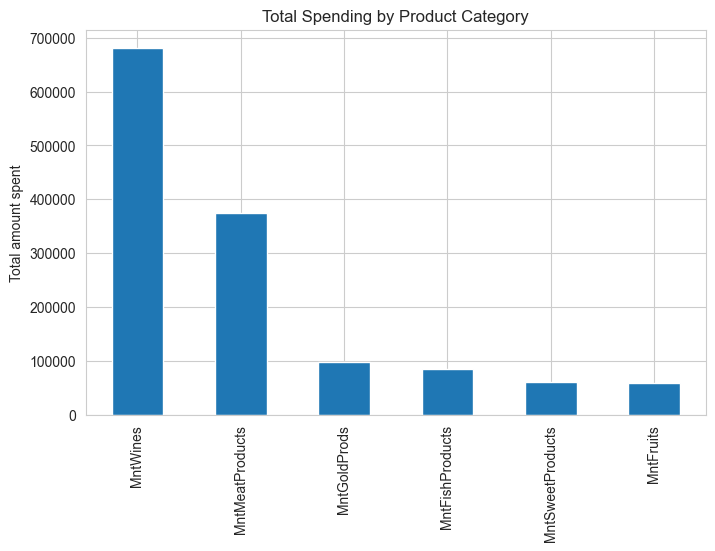

In [12]:
# Spending distribution across product categories
mnt_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
            'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df[mnt_cols].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Total Spending by Product Category')
plt.ylabel('Total amount spent')
plt.show()


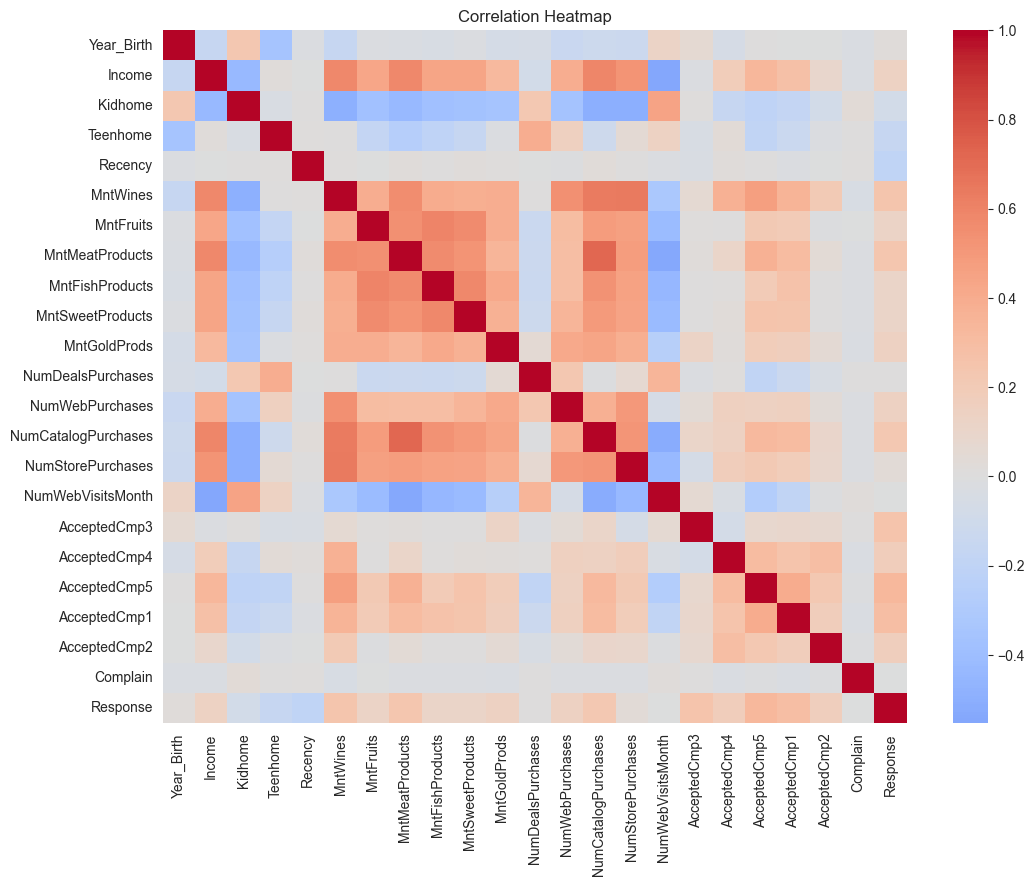

In [13]:
# Correlation heatmap of numeric features
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['ID', 'Z_CostContact', 'Z_Revenue'])
plt.figure(figsize=(12, 9))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap')
plt.show()


## 4. Data Cleaning and Feature Engineering

In [14]:
data = df.copy()

# Handle missing Income values with the median
data['Income'] = data['Income'].fillna(data['Income'].median())
print("Remaining missing values:", data['Income'].isna().sum())


Remaining missing values: 0


In [15]:
# Remove unrealistic outliers: very old birth years and extreme income
data['Age'] = reference_year - data['Year_Birth']

before = data.shape[0]
data = data[(data['Age'] <= 90) & (data['Income'] <= 200000)]
after = data.shape[0]
print(f"Removed {before - after} outlier rows ({before} -> {after})")


Removed 4 outlier rows (2240 -> 2236)


In [16]:
# Derived business features
data['Total_Spending'] = data[mnt_cols].sum(axis=1)

purchase_cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
data['Total_Purchases'] = data[purchase_cols].sum(axis=1)

data['Total_Campaigns_Accepted'] = (
    data['AcceptedCmp1'] + data['AcceptedCmp2'] + data['AcceptedCmp3'] +
    data['AcceptedCmp4'] + data['AcceptedCmp5'] + data['Response']
)

data['Children'] = data['Kidhome'] + data['Teenhome']

# Average order value (avoid divide-by-zero for customers with 0 purchases)
data['Avg_Order_Value'] = data['Total_Spending'] / data['Total_Purchases'].replace(0, np.nan)
data['Avg_Order_Value'] = data['Avg_Order_Value'].fillna(0)

data[['Age', 'Total_Spending', 'Total_Purchases', 'Total_Campaigns_Accepted',
      'Children', 'Avg_Order_Value']].head()


,Age,Total_Spending,Total_Purchases,Total_Campaigns_Accepted,Children,Avg_Order_Value
0,58,1617,22,1,0,73.500000
1,61,27,4,0,2,6.750000
2,50,776,20,0,0,38.800000
3,31,53,6,0,1,8.833333
4,34,422,14,0,1,30.142857


In [17]:
# Customer tenure: days since enrollment, relative to the most recent enrollment date in the data
data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'], format='%d-%m-%Y')
most_recent_enrollment = data['Dt_Customer'].max()
data['Customer_Tenure_Days'] = (most_recent_enrollment - data['Dt_Customer']).dt.days
data[['Dt_Customer', 'Customer_Tenure_Days']].head()


,Dt_Customer,Customer_Tenure_Days
0,2012-09-04,663
1,2014-03-08,113
2,2013-08-21,312
3,2014-02-10,139
4,2014-01-19,161


In [18]:
# Encode categorical variables (Education, Marital_Status) for use in regression/classification
data_encoded = pd.get_dummies(data, columns=['Education', 'Marital_Status'], drop_first=True)
print("Columns after encoding:", data_encoded.shape[1])


Columns after encoding: 45


## 5. RFM Feature Construction

Using the standard RFM framework:
- **Recency** — the existing `Recency` column (days since last purchase)
- **Frequency** — `Total_Purchases` (web + catalog + store purchases)
- **Monetary** — `Total_Spending` (sum across all product categories)


In [19]:
rfm = data[['ID', 'Recency', 'Total_Purchases', 'Total_Spending']].rename(
    columns={'Recency': 'Recency', 'Total_Purchases': 'Frequency', 'Total_Spending': 'Monetary'}
)
rfm.describe()


,ID,Recency,Frequency,Monetary
count,2236.000000,2236.000000,2236.000000,2236.000000
mean,5589.008497,49.116279,12.546512,605.986583
std,3244.826887,28.957284,7.206577,601.865156
min,0.000000,0.000000,0.000000,5.000000
25%,2828.250000,24.000000,6.000000,69.000000
50%,5454.500000,49.000000,12.000000,396.500000
75%,8421.750000,74.000000,18.000000,1045.500000
max,11191.000000,99.000000,32.000000,2525.000000


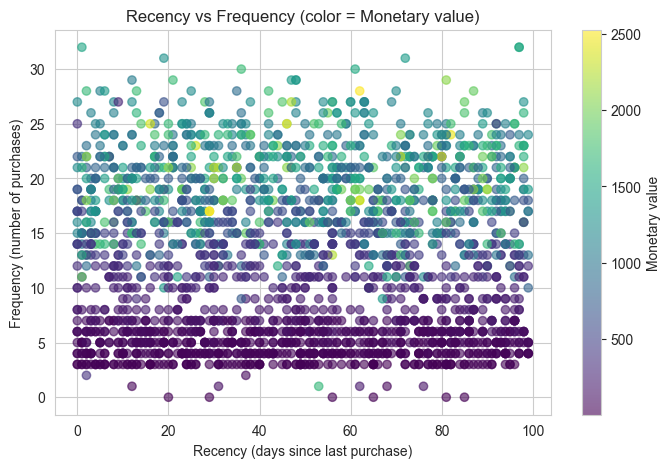

In [20]:
# Recency vs Frequency, colored by Monetary value
fig, ax = plt.subplots()
scatter = ax.scatter(rfm['Recency'], rfm['Frequency'], c=rfm['Monetary'], cmap='viridis', alpha=0.6)
ax.set_xlabel('Recency (days since last purchase)')
ax.set_ylabel('Frequency (number of purchases)')
ax.set_title('Recency vs Frequency (color = Monetary value)')
plt.colorbar(scatter, label='Monetary value')
plt.show()


## 6. Feature Scaling for Clustering

In [21]:
cluster_features = ['Recency', 'Total_Purchases', 'Total_Spending', 'Income',
                     'Avg_Order_Value', 'NumWebVisitsMonth', 'NumDealsPurchases']
cluster_data = data[cluster_features].copy()
cluster_data.head()


,Recency,Total_Purchases,Total_Spending,Income,Avg_Order_Value,NumWebVisitsMonth,NumDealsPurchases
0,58,22,1617,58138.0,73.500000,7,3
1,38,4,27,46344.0,6.750000,5,2
2,26,20,776,71613.0,38.800000,4,1
3,26,6,53,26646.0,8.833333,6,2
4,94,14,422,58293.0,30.142857,5,5


In [22]:
# Standardize features so no single scale (e.g. Income) dominates the distance metric
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_data)
cluster_scaled[:5]


array([[ 0.30685572,  1.31207969,  1.6801763 ,  0.28894655,  0.77148637,
         0.69286459,  0.34873831],
       [-0.38397129, -1.18619751, -0.9622024 , -0.262003  , -0.68319848,
        -0.13142124, -0.16869955],
       [-0.7984675 ,  1.03449334,  0.28254077,  0.91842301,  0.01526818,
        -0.54356416, -0.68613742],
       [-0.7984675 , -0.90861115, -0.91899369, -1.18218313, -0.63779633,
         0.28072168, -0.16869955],
       [ 1.55034434,  0.20173427, -0.30576241,  0.29618728, -0.17339721,
        -0.13142124,  1.38361403]])

## 7. Selecting the Number of Clusters

In [23]:
# Elbow method: inertia for k = 2..10
inertias = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(cluster_scaled)
    inertias.append(km.inertia_)


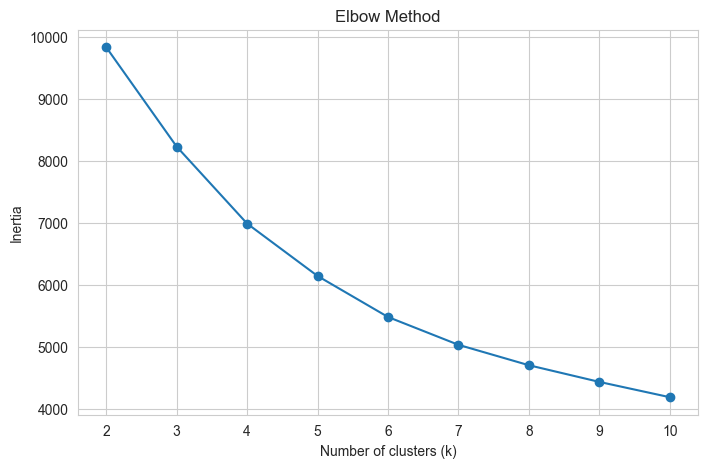

In [24]:
# Plot the elbow curve
plt.plot(list(k_range), inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()


In [25]:
# Silhouette score for the same range of k
sil_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(cluster_scaled)
    sil_scores.append(silhouette_score(cluster_scaled, labels))


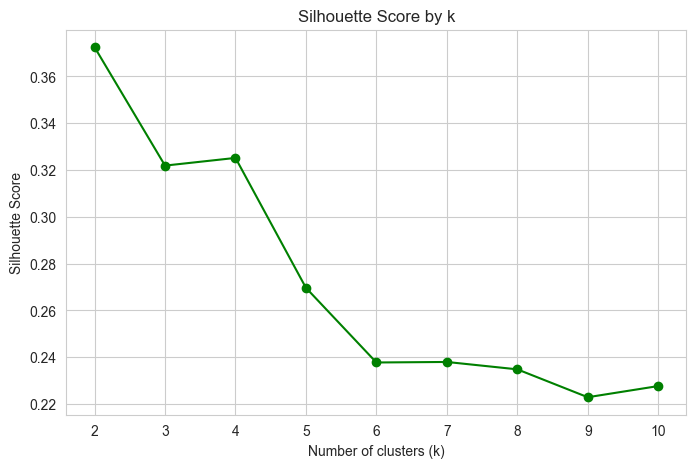

In [26]:
# Plot silhouette scores
plt.plot(list(k_range), sil_scores, marker='o', color='green')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by k')
plt.show()


## 8. Fit the Final K-Means Model

In [27]:
chosen_k = 4
kmeans_final = KMeans(n_clusters=chosen_k, init='k-means++', n_init=10, random_state=42)
data['Cluster'] = kmeans_final.fit_predict(cluster_scaled)
data['Cluster'].value_counts().sort_index()


Cluster
0    1035
1     729
2     471
3       1
Name: count, dtype: int64

In [28]:
print("Silhouette score (final model):", silhouette_score(cluster_scaled, data['Cluster']))
print("Inertia (final model):", kmeans_final.inertia_)


Silhouette score (final model): 0.32517538131036255
Inertia (final model): 6986.854640127297


### 8.1 Two-Dimensional Cluster Visualization (PCA)

In [29]:
# Reduce the scaled cluster features to 2 dimensions for visualization only
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(cluster_scaled)
data['PCA1'] = pca_components[:, 0]
data['PCA2'] = pca_components[:, 1]
print("Explained variance ratio:", pca.explained_variance_ratio_)


Explained variance ratio: [0.47997968 0.17070095]


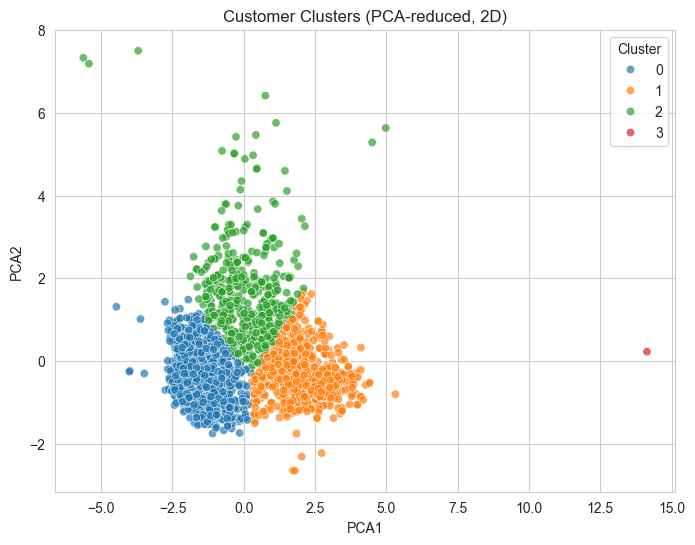

In [30]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='PCA1', y='PCA2', hue='Cluster', palette='tab10', alpha=0.7)
plt.title('Customer Clusters (PCA-reduced, 2D)')
plt.show()


## 9. Segment Profiling

In [31]:
cluster_profile = data.groupby('Cluster').agg(
    Num_Customers=('ID', 'count'),
    Avg_Spending=('Total_Spending', 'mean'),
    Avg_Frequency=('Total_Purchases', 'mean'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Order_Value=('Avg_Order_Value', 'mean'),
    Avg_Income=('Income', 'mean'),
    Avg_Deals_Usage=('NumDealsPurchases', 'mean'),
    Avg_Campaigns_Accepted=('Total_Campaigns_Accepted', 'mean')
).round(1)

cluster_profile['Revenue_Share_%'] = (
    data.groupby('Cluster')['Total_Spending'].sum() / data['Total_Spending'].sum() * 100
).round(1)

cluster_profile


,Num_Customers,Avg_Spending,Avg_Frequency,Avg_Recency,Avg_Order_Value,Avg_Income,Avg_Deals_Usage,Avg_Campaigns_Accepted,Revenue_Share_%
Cluster,,,,,,,,,
0,1035,103.3,6.0,48.9,14.6,34715.7,1.9,0.2,7.9
1,729,1264.7,19.1,49.9,68.0,74636.7,1.3,0.9,68.0
2,471,688.9,16.7,48.5,40.0,54721.4,4.9,0.4,23.9
3,1,1679.0,1.0,53.0,1679.0,51381.5,0.0,1.0,0.1


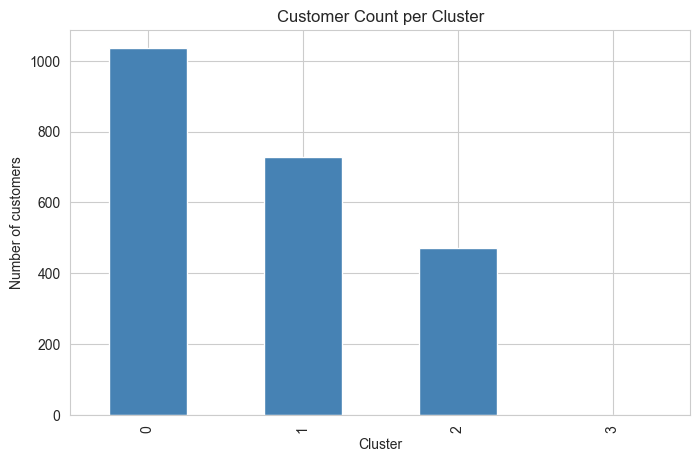

In [32]:
# Cluster-wise customer count
cluster_profile['Num_Customers'].plot(kind='bar', color='steelblue')
plt.title('Customer Count per Cluster')
plt.ylabel('Number of customers')
plt.xlabel('Cluster')
plt.show()


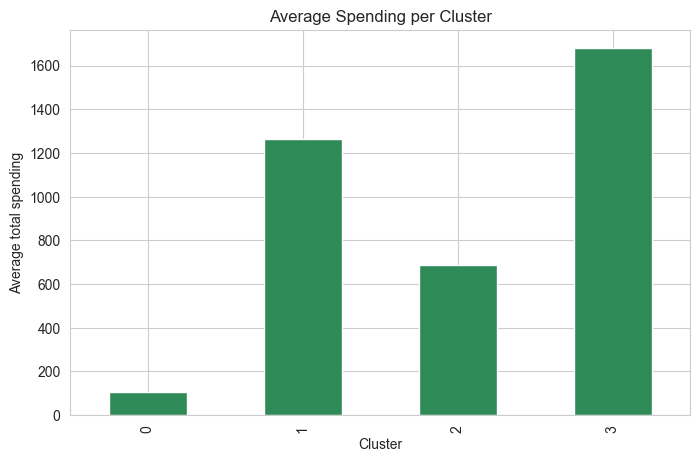

In [33]:
# Cluster-wise average spending
cluster_profile['Avg_Spending'].plot(kind='bar', color='seagreen')
plt.title('Average Spending per Cluster')
plt.ylabel('Average total spending')
plt.xlabel('Cluster')
plt.show()


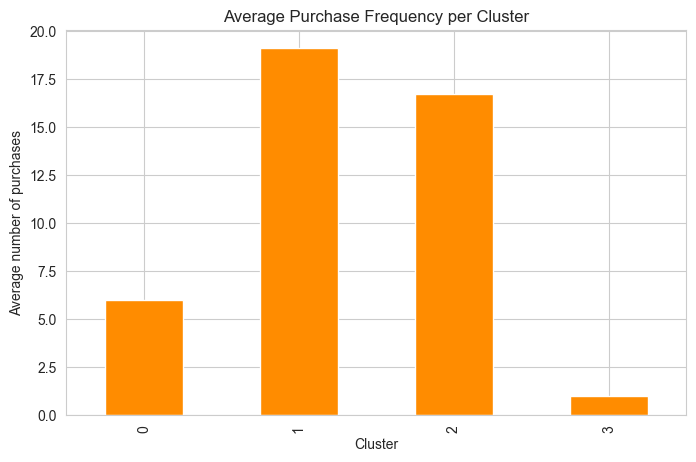

In [34]:
# Cluster-wise average purchase frequency
cluster_profile['Avg_Frequency'].plot(kind='bar', color='darkorange')
plt.title('Average Purchase Frequency per Cluster')
plt.ylabel('Average number of purchases')
plt.xlabel('Cluster')
plt.show()


## 10. Regression — Predicting Customer Spending

In [35]:
# Re-encode the cleaned+engineered dataframe (includes Cluster, Age, etc.)
model_df = pd.get_dummies(data, columns=['Education', 'Marital_Status'], drop_first=True)

reg_features = ['Income', 'Age', 'Children', 'Recency', 'NumWebVisitsMonth',
                'NumDealsPurchases', 'Total_Purchases', 'Customer_Tenure_Days']
reg_features += [c for c in model_df.columns if c.startswith('Education_') or c.startswith('Marital_Status_')]

X_reg = model_df[reg_features]
y_reg = model_df['Total_Spending']
X_reg.head()


,Income,Age,Children,Recency,NumWebVisitsMonth,NumDealsPurchases,Total_Purchases,Customer_Tenure_Days,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,58138.0,58,0,58,7,3,22,663,False,True,False,False,False,False,False,True,False,False,False
1,46344.0,61,2,38,5,2,4,113,False,True,False,False,False,False,False,True,False,False,False
2,71613.0,50,0,26,4,1,20,312,False,True,False,False,False,False,False,False,True,False,False
3,26646.0,31,1,26,6,2,6,139,False,True,False,False,False,False,False,False,True,False,False
4,58293.0,34,1,94,5,5,14,161,False,False,False,True,False,False,True,False,False,False,False


In [36]:
# Train/test split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Scale features for the linear models
reg_scaler = StandardScaler()
X_train_r_scaled = reg_scaler.fit_transform(X_train_r)
X_test_r_scaled = reg_scaler.transform(X_test_r)


In [37]:
# Baseline Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train_r_scaled, y_train_r)
y_pred_lin = lin_reg.predict(X_test_r_scaled)

print("Linear Regression:")
print("  MAE :", mean_absolute_error(y_test_r, y_pred_lin))
print("  RMSE:", np.sqrt(mean_squared_error(y_test_r, y_pred_lin)))
print("  R^2 :", r2_score(y_test_r, y_pred_lin))


Linear Regression:
  MAE : 199.57898764978523
  RMSE: 272.20129948932214
  R^2 : 0.8033794112132833


In [38]:
# Baseline Ridge Regression
ridge_reg = Ridge(alpha=1.0, random_state=42)
ridge_reg.fit(X_train_r_scaled, y_train_r)
y_pred_ridge = ridge_reg.predict(X_test_r_scaled)

print("Ridge Regression (baseline, alpha=1.0):")
print("  MAE :", mean_absolute_error(y_test_r, y_pred_ridge))
print("  RMSE:", np.sqrt(mean_squared_error(y_test_r, y_pred_ridge)))
print("  R^2 :", r2_score(y_test_r, y_pred_ridge))


Ridge Regression (baseline, alpha=1.0):
  MAE : 199.55593627941198
  RMSE: 272.19766532432794
  R^2 : 0.8033846613490634


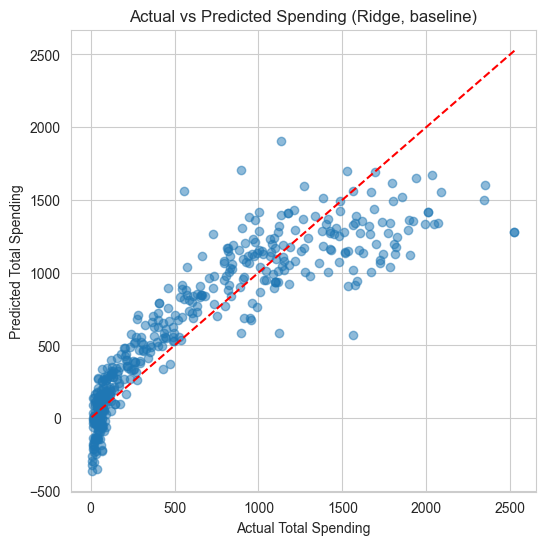

In [39]:
# Actual vs predicted spending (Ridge baseline)
plt.figure(figsize=(6, 6))
plt.scatter(y_test_r, y_pred_ridge, alpha=0.5)
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--')
plt.xlabel('Actual Total Spending')
plt.ylabel('Predicted Total Spending')
plt.title('Actual vs Predicted Spending (Ridge, baseline)')
plt.show()


### 10.1 Hyperparameter Tuning — Ridge Regression

In [40]:
# Tune alpha with GridSearchCV
ridge_param_grid = {'alpha': [0.01, 0.1, 1, 5, 10, 50, 100]}
ridge_grid = GridSearchCV(Ridge(random_state=42), ridge_param_grid,
                           scoring='neg_root_mean_squared_error', cv=5)
ridge_grid.fit(X_train_r_scaled, y_train_r)

print("Best alpha:", ridge_grid.best_params_)


Best alpha: {'alpha': 10}


In [41]:
# Evaluate the tuned Ridge model
best_ridge = ridge_grid.best_estimator_
y_pred_ridge_tuned = best_ridge.predict(X_test_r_scaled)

print("Ridge Regression (tuned):")
print("  MAE :", mean_absolute_error(y_test_r, y_pred_ridge_tuned))
print("  RMSE:", np.sqrt(mean_squared_error(y_test_r, y_pred_ridge_tuned)))
print("  R^2 :", r2_score(y_test_r, y_pred_ridge_tuned))


Ridge Regression (tuned):
  MAE : 199.3556667370501
  RMSE: 272.2063780602058
  R^2 : 0.8033720742834862


## 11. Classification — Predicting Purchase Likelihood

Target: `Response` (1 = accepted the most recent campaign, i.e. likely to respond to
future offers; 0 = did not respond). This identifies high-potential customers for the
next campaign without wasting budget on unlikely responders.


In [42]:
clf_features = ['Recency', 'Total_Purchases', 'Total_Spending', 'NumWebVisitsMonth',
                'NumDealsPurchases', 'Income', 'Age', 'Children', 'Complain',
                'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
                'Cluster']

X_clf = model_df[clf_features]
y_clf = model_df['Response']
print("Class balance:")
print(y_clf.value_counts(normalize=True).round(3))


Class balance:
Response
0    0.851
1    0.149
Name: proportion, dtype: float64


In [43]:
# Train/test split (stratified to preserve the class balance)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

clf_scaler = StandardScaler()
X_train_c_scaled = clf_scaler.fit_transform(X_train_c)
X_test_c_scaled = clf_scaler.transform(X_test_c)


In [44]:
# Baseline Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_c_scaled, y_train_c)
y_pred_log = log_reg.predict(X_test_c_scaled)
y_proba_log = log_reg.predict_proba(X_test_c_scaled)[:, 1]

print(classification_report(y_test_c, y_pred_log))


              precision    recall  f1-score   support

           0       0.89      0.97      0.93       381
           1       0.63      0.28      0.39        67

    accuracy                           0.87       448
   macro avg       0.76      0.63      0.66       448
weighted avg       0.85      0.87      0.85       448



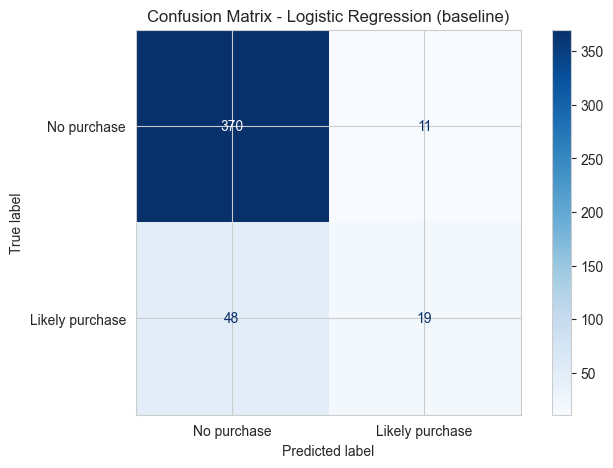

In [45]:
# Confusion matrix
cm = confusion_matrix(y_test_c, y_pred_log)
ConfusionMatrixDisplay(cm, display_labels=['No purchase', 'Likely purchase']).plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression (baseline)')
plt.show()


ROC-AUC (baseline): 0.863517060367454


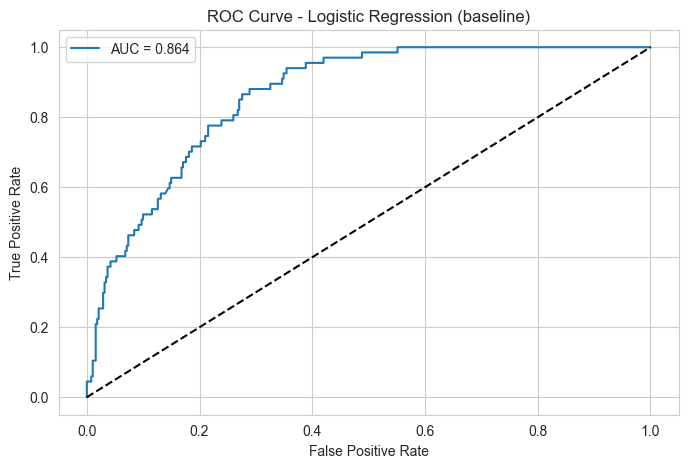

In [46]:
# ROC-AUC score and curve
auc_baseline = roc_auc_score(y_test_c, y_proba_log)
print("ROC-AUC (baseline):", auc_baseline)

fpr, tpr, _ = roc_curve(y_test_c, y_proba_log)
plt.plot(fpr, tpr, label=f'AUC = {auc_baseline:.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression (baseline)')
plt.legend()
plt.show()


### 11.1 Hyperparameter Tuning — Logistic Regression

In [47]:
# Tune C, penalty, and solver with GridSearchCV
log_param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}
log_grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42),
                         log_param_grid, scoring='roc_auc', cv=5)
log_grid.fit(X_train_c_scaled, y_train_c)

print("Best params:", log_grid.best_params_)


C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Use

Best params: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}


C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Use

In [48]:
# Evaluate the tuned classifier
best_log = log_grid.best_estimator_
y_pred_log_tuned = best_log.predict(X_test_c_scaled)
y_proba_log_tuned = best_log.predict_proba(X_test_c_scaled)[:, 1]

auc_tuned = roc_auc_score(y_test_c, y_proba_log_tuned)
print(classification_report(y_test_c, y_pred_log_tuned))
print("ROC-AUC (tuned):", auc_tuned)


              precision    recall  f1-score   support

           0       0.89      0.97      0.93       381
           1       0.66      0.28      0.40        67

    accuracy                           0.87       448
   macro avg       0.77      0.63      0.66       448
weighted avg       0.85      0.87      0.85       448

ROC-AUC (tuned): 0.863086144082736


## 12. Model Comparison Table

In [49]:
comparison = pd.DataFrame([
    {
        'Model': 'K-Means',
        'Objective': 'Customer segmentation',
        'Baseline Performance': 'See elbow/silhouette sweep above',
        'Tuned Performance': f'Silhouette = {silhouette_score(cluster_scaled, data["Cluster"]):.3f} (k={chosen_k})',
        'Selected Model': 'Yes'
    },
    {
        'Model': 'Linear Regression',
        'Objective': 'Predict customer spending',
        'Baseline Performance': f'RMSE={np.sqrt(mean_squared_error(y_test_r, y_pred_lin)):.1f}, R2={r2_score(y_test_r, y_pred_lin):.3f}',
        'Tuned Performance': 'Not tuned (no hyperparameters)',
        'Selected Model': 'No'
    },
    {
        'Model': 'Ridge Regression',
        'Objective': 'Predict customer spending',
        'Baseline Performance': f'RMSE={np.sqrt(mean_squared_error(y_test_r, y_pred_ridge)):.1f}, R2={r2_score(y_test_r, y_pred_ridge):.3f}',
        'Tuned Performance': f'RMSE={np.sqrt(mean_squared_error(y_test_r, y_pred_ridge_tuned)):.1f}, R2={r2_score(y_test_r, y_pred_ridge_tuned):.3f}',
        'Selected Model': 'Yes'
    },
    {
        'Model': 'Logistic Regression',
        'Objective': 'Predict purchase likelihood',
        'Baseline Performance': f'AUC={auc_baseline:.3f}',
        'Tuned Performance': f'AUC={auc_tuned:.3f}',
        'Selected Model': 'Yes'
    },
])
comparison


,Model,Objective,Baseline Performance,Tuned Performance,Selected Model
0,K-Means,Customer segmentation,See elbow/silhouette sweep above,Silhouette = 0.325 (k=4),Yes
1,Linear Regression,Predict customer spending,"RMSE=272.2, R2=0.803",Not tuned (no hyperparameters),No
2,Ridge Regression,Predict customer spending,"RMSE=272.2, R2=0.803","RMSE=272.2, R2=0.803",Yes
3,Logistic Regression,Predict purchase likelihood,AUC=0.864,AUC=0.863,Yes
